# RUL Prediction for Aircraft Engines

- **Objective**
  - Predict Remaining Useful Life (RUL) using NASA CMAPSS FD001 dataset with SHAP.
  - Early RUL capping to stabilize targets
  - Temporal windowing for sequence modeling
  - Model-specific feature scaling

- **Key Findings**
  - LSTM achieved the best overall performance
  - Effective at capturing temporal degradation patterns

- **Explainability (XAI)**
  - SHAP used to interpret model predictions
  - Identifies physically meaningful degradation features
  - Improves model transparency and trust

- **Conclusions**
  - Trade-offs exist between model complexity and performance
  - Deep learning models outperform traditional methods in temporal tasks

Dataset Research Paper: https://ntrs.nasa.gov/api/citations/20090029214/downloads/20090029214.pdf  
Dataset : https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data

Concise summary of this modelling is available in the provided slide (study excludes LSTM & TSmixer).

# 1.0 Preprocessing

### 1.1 Preliminary Functions

In [1]:
import sys
print(sys.executable)

c:\Users\tvlan\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
!c:\Users\tvlan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade setuptools pip
!c:\Users\tvlan\AppData\Local\Programs\Python\Python310\python.exe -m pip install numpy==1.26.4

In [3]:
# Dependencies
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
import os
from sklearn.svm import SVR
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from scipy.stats import uniform, expon, randint

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import shap
import tensorflow as tf
import joblib
import numpy as np
import matplotlib.pyplot as plt



#from google.colab import drive  # Use this line if running in Google Colab
#drive.mount('/content/drive')

np.random.seed(44)

In [4]:
# Calculate the target RUL values with optional early RUL capping
def process_targets(data_length, early_rul = None):

    if early_rul == None:
        return np.arange(data_length-1, -1, -1)
    else:
        early_rul_duration = data_length - early_rul
        if early_rul_duration <= 0:
            return np.arange(data_length-1, -1, -1)
        else:
            return np.append(early_rul*np.ones(shape = (early_rul_duration,)), np.arange(early_rul-1, -1, -1))

In [5]:
# Process input data into overlapping windows with optional target extraction
def process_input_data_with_targets(input_data, target_data = None, window_length = 1, shift = 1):

    num_batches = int(np.floor((len(input_data) - window_length)/shift)) + 1
    num_features = input_data.shape[1]
    output_data = np.repeat(np.nan, repeats = num_batches * window_length * num_features).reshape(num_batches, window_length,
                                                                                                  num_features)
    if target_data is None:
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
        return output_data
    else:
        output_targets = np.repeat(np.nan, repeats = num_batches)
        for batch in range(num_batches):
            output_data[batch,:,:] = input_data[(0+shift*batch):(0+shift*batch+window_length),:]
            output_targets[batch] = target_data[(shift*batch + (window_length-1))]
        return output_data, output_targets

In [6]:
# Process test data into overlapping windows
def process_test_data(test_data_for_an_engine, window_length, shift, num_test_windows = 1):

    max_num_test_batches = int(np.floor((len(test_data_for_an_engine) - window_length)/shift)) + 1
    if max_num_test_batches < num_test_windows:
        required_len = (max_num_test_batches -1)* shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        return batched_test_data_for_an_engine, max_num_test_batches
    else:
        required_len = (num_test_windows - 1) * shift + window_length
        batched_test_data_for_an_engine = process_input_data_with_targets(test_data_for_an_engine[-required_len:, :],
                                                                          target_data = None,
                                                                          window_length = window_length, shift = shift)
        return batched_test_data_for_an_engine, num_test_windows

In [7]:
# Data processing function
def windows_performance(window_length=1,shift =1 ,num_last = 5, scaling = False , download = False):
      
      train_data = pd.read_csv(rf"C:\Users\tvlan\OneDrive\Documents\Machine Learning Lect\1.0 Project\1.0 Nasa_Dataset_Ori_Code\CMAPSSDatanasa\train_FD001.txt", sep = "\s+", header = None)
      test_data = pd.read_csv(rf"C:\Users\tvlan\OneDrive\Documents\Machine Learning Lect\1.0 Project\1.0 Nasa_Dataset_Ori_Code\CMAPSSDatanasa\test_FD001.txt", sep = "\s+", header = None)
      true_rul = pd.read_csv(rf"C:\Users\tvlan\OneDrive\Documents\Machine Learning Lect\1.0 Project\1.0 Nasa_Dataset_Ori_Code\CMAPSSDatanasa\RUL_FD001.txt", sep = '\s+', header = None)
      
      window_length = window_length
      shift = shift
      early_rul = 125
      processed_train_data = []
      processed_train_targets = []

      num_test_windows = num_last
      processed_test_data = []
      num_test_windows_list = []

      columns_to_be_dropped = [0,1,2,3,4,5,9,10,14,20,22,23]

      train_data_first_column = train_data[0]
      test_data_first_column = test_data[0]

      true_rul_full = []

      true_rul_full = []

      for i in test_data[0].unique():
          count = len(test_data[test_data[0] == i])
          true_rul_position = true_rul.iloc[i - 1, 0]

          rul_sequence = list(range(
              true_rul_position + count - 1,
              true_rul_position - 1,
              -1
          ))

          true_rul_full.extend(rul_sequence)

      #  Apply early RUL cap ONCE
      true_rul_full = [min(x, early_rul) for x in true_rul_full]  

      true_rul  = pd.DataFrame(true_rul_full)

      last_idx = (
            test_data
            .groupby(0, group_keys=False)
            .tail(num_last)
            .index
        )
      true_rul = true_rul.loc[last_idx]

      print(last_idx)

      if scaling == "Standard":
        # Scale data for all engines
        scaler = StandardScaler()
        train_data = scaler.fit_transform(train_data)
        test_data = scaler.transform(test_data)

        train_data = pd.DataFrame(data = np.c_[train_data_first_column, train_data])
        test_data = pd.DataFrame(data = np.c_[test_data_first_column, test_data])


      elif scaling == "MinMax":
            # Scale data for all engines
            scaler = MinMaxScaler()
            train_data = scaler.fit_transform(train_data)
            test_data = scaler.transform(test_data)

            train_data = pd.DataFrame(data = np.c_[train_data_first_column, train_data])
            test_data = pd.DataFrame(data = np.c_[test_data_first_column, test_data])

      if download == True:
          joblib.dump(scaler, rf"{scaling}.pkl")


      num_machines = np.min([len(train_data[0].unique()), len(test_data[0].unique())])
      
      print("Number of machines: ", num_machines)

      for i in np.arange(1, num_machines + 1):

          temp_train_data = train_data[train_data[0] == i].drop(columns=columns_to_be_dropped).values
          temp_test_data = test_data[test_data[0] == i].drop(columns=columns_to_be_dropped).values

          # Debugging: Print lengths of train and test data for each engine
          #print(f"Engine {i}: Train data length = {len(temp_train_data)}, Test data length = {len(temp_test_data)}")

          # Verify if data of given window length can be extracted from both training and test data
          if (len(temp_test_data) < window_length):
              print("Test engine {} doesn't have enough data for window_length of {}".format(i, window_length))
              raise AssertionError("Window length is larger than number of data points for some engines. "
                                  "Try decreasing window length.")
          elif (len(temp_train_data) < window_length):
              print("Train engine {} doesn't have enough data for window_length of {}".format(i, window_length))
              raise AssertionError("Window length is larger than number of data points for some engines. "
                                  "Try decreasing window length.")

          temp_train_targets = process_targets(data_length = temp_train_data.shape[0], early_rul = early_rul)
          data_for_a_machine, targets_for_a_machine = process_input_data_with_targets(temp_train_data, temp_train_targets,
                                                                                      window_length = window_length, shift = shift)

          # Prepare test data
          test_data_for_an_engine, num_windows = process_test_data(temp_test_data, window_length = window_length, shift = shift,
                                                                  num_test_windows = num_test_windows)

          # Debugging: Print number of windows created for each engine
          #print(f"Engine {i}: Number of test windows = {num_windows}")
          
          processed_train_data.append(data_for_a_machine)
          processed_train_targets.append(targets_for_a_machine)

          processed_test_data.append(test_data_for_an_engine)
          num_test_windows_list.append(num_windows)

      processed_train_data = np.concatenate(processed_train_data)
      processed_train_targets = np.concatenate(processed_train_targets)
      processed_test_data = np.concatenate(processed_test_data)
      true_rul = true_rul[0].values


       # Shuffle data
      index = np.random.permutation(len(processed_train_targets))
      processed_train_data, processed_train_targets = processed_train_data[index], processed_train_targets[index]
    

      print("Processed trianing data shape: ", processed_train_data.shape)
      print("Processed training ruls shape: ", processed_train_targets.shape)
      print("Processed test data shape: ", processed_test_data.shape)
      print("True RUL shape: ", true_rul.shape)

      if scaling != "MinMax":
        processed_train_data = processed_train_data.reshape(
        processed_train_data.shape[0],
        processed_train_data.shape[1] * processed_train_data.shape[2]
    )

        processed_test_data = processed_test_data.reshape(
        processed_test_data.shape[0],
        processed_test_data.shape[1] * processed_test_data.shape[2]
    )

      print("Processed train data shape: ", processed_train_data.shape)
      print("Processed test data shape: ", processed_test_data.shape)

      return processed_train_data, processed_train_targets, processed_test_data, true_rul,num_test_windows_list

In [8]:
# CNN model creation and compilation

def create_compiled_model(window_length, n_features):
    model = tf.keras.Sequential([
        layers.Conv1D(
            128, 5, activation="relu",
            padding="same",
            input_shape=(window_length, n_features)
        ),
        layers.Conv1D(96, 5, activation="relu", padding="same"),
        layers.Conv1D(32, 3, activation="relu", padding="same"),

        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse"
    )
    return model


In [9]:
# Learning rate scheduler
def scheduler(epoch):
    if epoch < 15:
        return 0.001
    else:
        return 0.0001

In [10]:
# S-score computation
def compute_s_score(rul_true, rul_pred):
    """
    Both rul_true and rul_pred should be 1D numpy arrays.
    """
    diff = rul_pred - rul_true
    return np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1))

# 2.0 Modelling

Modelling is performed with linear regression (baseline model), SVR , Random Forest, CNN, LSTM & TSMixer (Transformer Based). 

Window Size for each model :

`Linear Regression` : `25`,
`SVR` : `1`,
`Random Forest` : `1`,
`CNN` : `25`
`LSTM` : `25`
`TSMixer` : `25`


Window Size is derived based on experimentation for both SVR and Random Forest. Running SVR and Random Forest with larger windows is computationally intensive hence window size of 1 is utilized.

Epoch is set at `25` due to computation limitation. 

Below is a Universal function for Linear Regression, SVR and Random Forest with Hyperparameter tuning option.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform, expon, randint
from sklearn.linear_model import LinearRegression


def conventional_modelling(model, window_length, shift, num_last, hyperparameter_tuning, download = False):

        model_choice =  model.lower()

        if  model_choice == "svr" or  model_choice == "linear regression":
              scaling = "Standard"
        else:
              scaling = False

        
        processed_train_data, processed_train_targets, processed_test_data, true_rul, num_test_windows_list = windows_performance(window_length=window_length,
                                                                                                            shift=shift,
                                                                                                            num_last=num_last,
                                                                                                            scaling=scaling,
                                                                                                            download = download
                                                                                                            )

        # Validation Split for Hyperparameter Tuning
    
        if  model_choice == "svr":
            target_scaler = StandardScaler()
            processed_train_targets = target_scaler.fit_transform(processed_train_targets.reshape(-1, 1)).reshape(-1)
        
            if download == True :
                joblib.dump(target_scaler, f"target_scaler{model}.joblib")
            
        
        models = {
                "linear regression" : (LinearRegression(),{}),
                "svr" : (SVR(),{
                    "C" : expon(scale =10),
                    "gamma" : ["scale","auto"] + list(np.logspace(-3,0,4)),
                    "kernel" : ["linear","rbf"],
                    "epsilon" : uniform(0.01,1)
                }),
                "random forest" : (RandomForestRegressor(),{
                    "n_estimators": randint(50,200),
                    "max_depth" : randint(10,50),
                    "min_samples_split": randint(2,10)
                }),
                }
        
        predictor = models[ model_choice][0]

        hp_results = {}

        pred_Hp = {}

        #target_scaler = []

        predictor.fit(processed_train_data, processed_train_targets)
        rul_pred = predictor.predict(processed_test_data)

        if download == True:
          joblib.dump(predictor, f"{model}_model.pkl")

        if  model_choice == "svr":
            rul_pred = target_scaler.inverse_transform(rul_pred.reshape(-1, 1)).reshape(-1)

        preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])

        RMSE = np.sqrt(mean_squared_error(true_rul, rul_pred))
        MAE = mean_absolute_error(true_rul, rul_pred)
        R2 = r2_score(true_rul, rul_pred)
        S_score = compute_s_score(true_rul, rul_pred)

        ori_results = {
        "MAE": MAE,
        "R2": R2,
        "RMSE": RMSE,
        "S-score": S_score
        }


        # Hyperparameter Tuning
        if hyperparameter_tuning == True :
                
            Hyperparameter = (models[model_choice][0], models[model_choice][1])
            
            search = RandomizedSearchCV (Hyperparameter[0],param_distributions = Hyperparameter[1], n_iter =10, cv=3, 
                            scoring = "r2", random_state = 42 ,n_jobs =-1, verbose =2
                            )

            search.fit (processed_train_data, processed_train_targets)
            best_model = search.best_estimator_
            best_params = search.best_params_

            if download == True:
                joblib.dump(best_model, f"{model}hp_model.pkl")

            pred_Hp = best_model.predict(processed_test_data)

            if  model_choice == "svr":
                pred_Hp = target_scaler.inverse_transform(pred_Hp.reshape(-1, 1)).reshape(-1)

            RMSE_Hp = np.sqrt(mean_squared_error(true_rul, pred_Hp))
            mae_Hp = mean_absolute_error(true_rul, pred_Hp)
            r2_Hp = r2_score(true_rul, pred_Hp)
            S_score = compute_s_score(true_rul, pred_Hp)


            hp_results = {
                    "best_params": best_params,
                    "best_model": best_model,
                    "MAE": mae_Hp,
                    "R2": r2_Hp,
                    "RMSE": RMSE_Hp,
                    "S-score": S_score

            }

        return ori_results, rul_pred, true_rul, hp_results, pred_Hp



Below is the preprocessing and modelling function for CNN

In [12]:
from scipy.stats import randint
from scipy.stats import uniform, expon, randint

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


def CNN_modelling(window_length, shift, num_last, scaling, hyperparameter_tuning, download = False):
            processed_train_data, processed_train_targets, processed_test_data, true_rul, num_test_windows_list = windows_performance(window_length=window_length,
                                                                                                                shift=shift,
                                                                                                                num_last=num_last,
                                                                                                                scaling=scaling,
                                                                                                                download = download
                                                                                                                )

            processed_train_data, processed_val_data, processed_train_targets, processed_val_targets = train_test_split(processed_train_data,
                                                                                                                        processed_train_targets,
                                                                                                                        test_size = 0.2,
                                                                                                                        random_state = 42)

            print("Processed train data shape: ", processed_train_data.shape)
            print("Processed validation data shape: ", processed_val_data.shape)
            print("Processed train targets shape: ", processed_train_targets.shape)
            print("Processed validation targets shape: ", processed_val_targets.shape)


            target_scaler = MinMaxScaler(feature_range = (0, 1))
            processed_train_targets = target_scaler.fit_transform(processed_train_targets.reshape(-1, 1)).reshape(-1)
            processed_val_targets = target_scaler.transform(processed_val_targets.reshape(-1, 1)).reshape(-1)

            if download == True:
                joblib.dump(target_scaler, "target_scaler_cnn.pkl")

            callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose = 1)

            model = create_compiled_model(window_length, processed_train_data.shape[2])
            history = model.fit(processed_train_data, processed_train_targets, epochs = 25,
                                validation_data = (processed_val_data, processed_val_targets),
                                callbacks = [callback],
                                batch_size = 64, verbose = 2)
            
            if download == True:
                    model.save("cnn_model.keras")

            rul_pred_scaled = model.predict(processed_test_data).reshape(-1)
            rul_pred = target_scaler.inverse_transform(rul_pred_scaled.reshape(-1, 1)).reshape(-1)

            #preds_for_each_engine = np.split(rul_pred, np.cumsum(num_test_windows_list)[:-1])

            RMSE = np.sqrt(mean_squared_error(true_rul, rul_pred))
            mae = mean_absolute_error(true_rul, rul_pred)
            r2 = r2_score(true_rul, rul_pred)
            S_score = compute_s_score(true_rul, rul_pred)

            ori_results = {
            "MAE": mae,
            "R2": r2,
            "RMSE": RMSE,
            "S-score": S_score
            }

            ori_results

            return ori_results, rul_pred, true_rul

##### Below is the preprocessing and modelling of lstm

In [13]:
from scipy.stats import randint, uniform, expon
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


def create_compiled_lstm_model(window_length, num_features,
                               lstm_units_1=64, lstm_units_2=32,
                               dropout_rate=0.2, learning_rate=1e-3):
    model = Sequential([
        layers.Input(shape=(window_length, num_features)),

        # First LSTM layer — return sequences so the second LSTM gets full output
        layers.LSTM(lstm_units_1, return_sequences=True),
        layers.Dropout(dropout_rate),

        # Second LSTM layer — return sequences=False to collapse time dimension
        layers.LSTM(lstm_units_2, return_sequences=False),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


def LSTM_modelling(window_length, shift, num_last, scaling,
                   hyperparameter_tuning, download=False):

    processed_train_data, processed_train_targets, \
    processed_test_data, true_rul, num_test_windows_list = windows_performance(
        window_length=window_length,
        shift=shift,
        num_last=num_last,
        scaling=scaling,
        download=download
    )

    processed_train_data, processed_val_data, \
    processed_train_targets, processed_val_targets = train_test_split(
        processed_train_data,
        processed_train_targets,
        test_size=0.2,
        random_state=42
    )

    print("Processed train data shape:      ", processed_train_data.shape)
    print("Processed validation data shape: ", processed_val_data.shape)
    print("Processed train targets shape:   ", processed_train_targets.shape)
    print("Processed validation targets shape:", processed_val_targets.shape)

    # Scale targets
    target_scaler = MinMaxScaler(feature_range=(0, 1))
    processed_train_targets = target_scaler.fit_transform(
        processed_train_targets.reshape(-1, 1)
    ).reshape(-1)
    processed_val_targets = target_scaler.transform(
        processed_val_targets.reshape(-1, 1)
    ).reshape(-1)

    if download:
        joblib.dump(target_scaler, "target_scaler_lstm.pkl")

    callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)

    # Build and train LSTM model
    model = create_compiled_lstm_model(
        window_length,
        processed_train_data.shape[2]
    )

    history = model.fit(
        processed_train_data,
        processed_train_targets,
        epochs=25,
        validation_data=(processed_val_data, processed_val_targets),
        callbacks=[callback],
        batch_size=64,
        verbose=2
    )

    if download:
        model.save("lstm_model.keras")

    # Predict and inverse-transform
    rul_pred_scaled = model.predict(processed_test_data).reshape(-1)
    rul_pred = target_scaler.inverse_transform(
        rul_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    RMSE    = np.sqrt(mean_squared_error(true_rul, rul_pred))
    mae     = mean_absolute_error(true_rul, rul_pred)
    r2      = r2_score(true_rul, rul_pred)
    S_score = compute_s_score(true_rul, rul_pred)

    ori_results = {
        "MAE":     mae,
        "R2":      r2,
        "RMSE":    RMSE,
        "S-score": S_score
    }

    return ori_results, rul_pred, true_rul

#### Below is the preprocessing and modelling code for TSMixer (Transformer)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model


def TSMixerBlock(x, num_features, ff_dim, dropout_rate):
    """One TSMixer block: time mixing → feature mixing."""

    # --- Time mixing (across timesteps, per feature) ---
    residual = x
    x = layers.LayerNormalization()(x)
    x = layers.Permute((2, 1))(x)                          # (batch, features, time)
    x = layers.Dense(x.shape[-1], activation='relu')(x)    # mix across time
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Permute((2, 1))(x)                          # (batch, time, features)
    x = layers.Add()([x, residual])

    # --- Feature mixing (across features, per timestep) ---
    residual = x
    x = layers.LayerNormalization()(x)
    x = layers.Dense(ff_dim, activation='relu')(x)         # expand
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(num_features)(x)                      # project back
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Add()([x, residual])

    return x


def create_compiled_tsmixer_model(window_length, num_features,
                                  num_blocks=4, ff_dim=64,
                                  dropout_rate=0.1, learning_rate=1e-3):
    inputs = tf.keras.Input(shape=(window_length, num_features))
    x = inputs

    # Stack N TSMixer blocks
    for _ in range(num_blocks):
        x = TSMixerBlock(x, num_features, ff_dim, dropout_rate)

    # Global average pooling over time → regression head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


def TSMixer_modelling(window_length, shift, num_last, scaling,
                      hyperparameter_tuning, download=False):

    processed_train_data, processed_train_targets, \
    processed_test_data, true_rul, num_test_windows_list = windows_performance(
        window_length=window_length,
        shift=shift,
        num_last=num_last,
        scaling=scaling,
        download=download
    )

    processed_train_data, processed_val_data, \
    processed_train_targets, processed_val_targets = train_test_split(
        processed_train_data,
        processed_train_targets,
        test_size=0.2,
        random_state=42
    )

    print("Processed train data shape:        ", processed_train_data.shape)
    print("Processed validation data shape:   ", processed_val_data.shape)
    print("Processed train targets shape:     ", processed_train_targets.shape)
    print("Processed validation targets shape:", processed_val_targets.shape)

    # Scale targets
    target_scaler = MinMaxScaler(feature_range=(0, 1))
    processed_train_targets = target_scaler.fit_transform(
        processed_train_targets.reshape(-1, 1)
    ).reshape(-1)
    processed_val_targets = target_scaler.transform(
        processed_val_targets.reshape(-1, 1)
    ).reshape(-1)

    if download:
        joblib.dump(target_scaler, "target_scaler_tsmixer.pkl")

    callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)

    # Build and train TSMixer model
    model = create_compiled_tsmixer_model(
        window_length,
        processed_train_data.shape[2]
    )
    model.summary()

    history = model.fit(
        processed_train_data,
        processed_train_targets,
        epochs=25,
        validation_data=(processed_val_data, processed_val_targets),
        callbacks=[callback],
        batch_size=64,
        verbose=2
    )

    if download:
        model.save("tsmixer_model.keras")

    # Predict and inverse-transform
    rul_pred_scaled = model.predict(processed_test_data).reshape(-1)
    rul_pred = target_scaler.inverse_transform(
        rul_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    RMSE    = np.sqrt(mean_squared_error(true_rul, rul_pred))
    mae     = mean_absolute_error(true_rul, rul_pred)
    r2      = r2_score(true_rul, rul_pred)
    S_score = compute_s_score(true_rul, rul_pred)

    ori_results = {
        "MAE":     mae,
        "R2":      r2,
        "RMSE":    RMSE,
        "S-score": S_score
    }

    return ori_results, rul_pred, true_rul

## 2.1 Linear Regression

In [15]:
window_length= 25
shift = 1
num_last = 5
hyperparameter_tuning = False
model = "linear regression"
download = True

LR_results= conventional_modelling(model, window_length, shift, num_last,hyperparameter_tuning, download = download)

Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (18231, 25, 15)
Processed training ruls shape:  (18231,)
Processed test data shape:  (500, 25, 15)
True RUL shape:  (500,)
Processed train data shape:  (18231, 375)
Processed test data shape:  (500, 375)


In [26]:
print("Linear Regression Performance at window length 25:")
LR_results[0]

Linear Regression Performance at window length 25:


{'MAE': 13.944903709163286,
 'R2': 0.8167551078169304,
 'RMSE': 17.040234062009727,
 'S-score': 2544.958078200226}

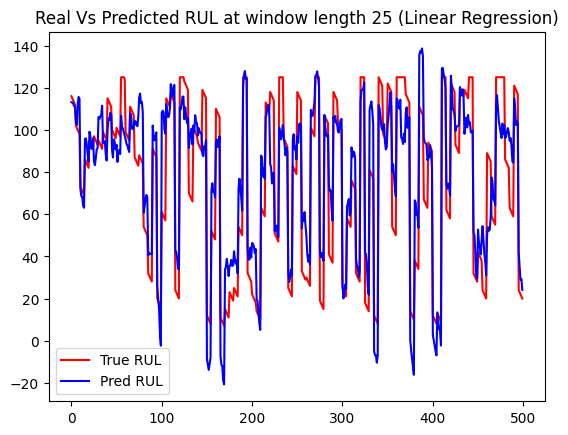

In [27]:
true_rul = LR_results[2]
rul_pred = LR_results[1]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 25 (Linear Regression)")
plt.legend()
plt.show()

## 2.2 SVR

In [28]:
window_length=1
shift = 1
num_last = 5
hyperparameter_tuning = True
model = "SVR"

SVR_results = conventional_modelling(model, window_length, shift, num_last,hyperparameter_tuning)


Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (20631, 1, 15)
Processed training ruls shape:  (20631,)
Processed test data shape:  (500, 1, 15)
True RUL shape:  (500,)
Processed train data shape:  (20631, 15)
Processed test data shape:  (500, 15)
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [39]:
window_length=25
shift = 1
num_last = 5
hyperparameter_tuning = False
model = "SVR"

SVR_results = conventional_modelling(model, window_length, shift, num_last,hyperparameter_tuning)

Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (18231, 25, 15)
Processed training ruls shape:  (18231,)
Processed test data shape:  (500, 25, 15)
True RUL shape:  (500,)
Processed train data shape:  (18231, 375)
Processed test data shape:  (500, 375)


In [29]:
print("Best Performance at window length 5:")
print(SVR_results[0])

print("Best Performance after Hyperparameter Tuning at window length 5:")
print(SVR_results[3])

Best Performance at window length 5:
{'MAE': 14.503047720060316, 'R2': 0.7350355100043466, 'RMSE': 20.490542380357567, 'S-score': 9279.152458683362}
Best Performance after Hyperparameter Tuning at window length 5:
{'best_params': {'C': 15.379360110309118, 'epsilon': 0.20967378215835974, 'gamma': 0.01, 'kernel': 'rbf'}, 'best_model': SVR(C=15.379360110309118, epsilon=0.20967378215835974, gamma=0.01), 'MAE': 14.803745957201526, 'R2': 0.7351766308728533, 'RMSE': 20.485084991965792, 'S-score': 10067.633895037818}


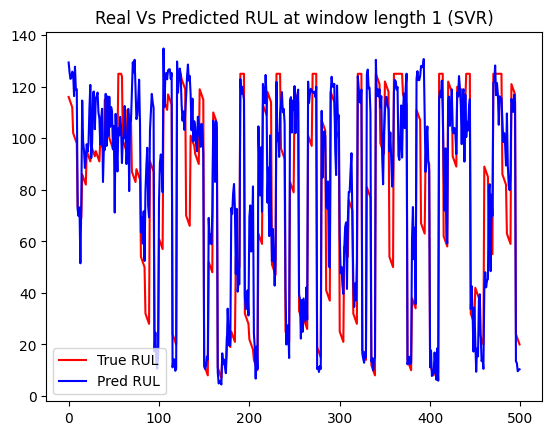

In [30]:
true_rul = SVR_results[2]
rul_pred = SVR_results[4]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 1 (SVR)")
plt.legend()
plt.show()

## 2.3 Random Forest

In [31]:
# Too slow to run window more than 5
window_length= 1
shift = 1
num_last = 5
hyperparameter_tuning = True
model = "Random Forest"

RF_results = conventional_modelling(model, window_length, shift, num_last,hyperparameter_tuning)
 

Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (20631, 1, 14)
Processed training ruls shape:  (20631,)
Processed test data shape:  (500, 1, 14)
True RUL shape:  (500,)
Processed train data shape:  (20631, 14)
Processed test data shape:  (500, 14)
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [32]:
print("Best Performance at window length 5:")
print(RF_results[0])

print("Best Performance after Hyperparameter Tuning at window length 5:")
print(RF_results[3])

Best Performance at window length 5:
{'MAE': 13.457360000000001, 'R2': 0.7779685109327342, 'RMSE': 18.757152214555386, 'S-score': 6281.06750155798}
Best Performance after Hyperparameter Tuning at window length 5:
{'best_params': {'max_depth': 11, 'min_samples_split': 9, 'n_estimators': 70}, 'best_model': RandomForestRegressor(max_depth=11, min_samples_split=9, n_estimators=70), 'MAE': 13.20526918641775, 'R2': 0.7833089185793748, 'RMSE': 18.530201223459894, 'S-score': 6266.617788943037}


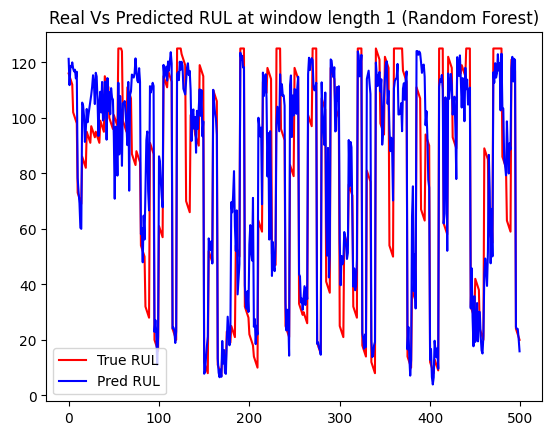

In [33]:
true_rul = RF_results[2]
rul_pred = RF_results[4]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 1 (Random Forest)")
plt.legend()
plt.show()

## 2.4 CNN

CNN preprocessing and training function.

In [ ]:
window_length= 25
shift = 1
num_last = 5
hyperparameter_tuning = False
scaling = "MinMax"

CNN_results = CNN_modelling(window_length, shift, num_last, scaling, hyperparameter_tuning, download = True)

In [ ]:
print("Best Performance at window length 25 (CNN):")
print(CNN_results[0])
    

Best Performance at window length 25 (CNN):
{'MAE': 10.406259536743164, 'R2': 0.8738511800765991, 'RMSE': 14.138429452309394, 'S-score': 1992.5194052666818}


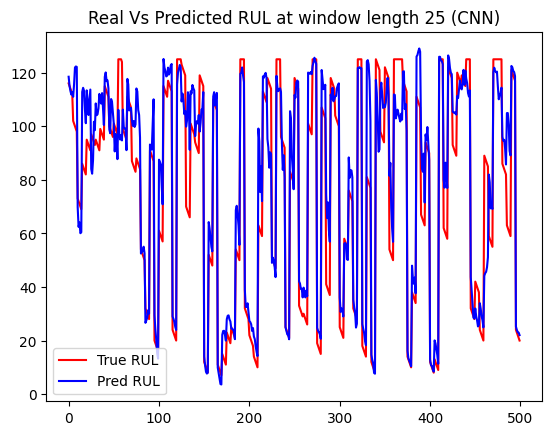

In [ ]:
true_rul = CNN_results[2]
rul_pred = CNN_results[1]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 25 (CNN)")
plt.legend()
plt.show()

# 2.5 LSTM

In [18]:
window_length= 25
num_features = 15
shift = 1
num_last = 5
scaling = "MinMax"

LSTM_rresults = LSTM_modelling(window_length, shift, num_last, scaling,
                   hyperparameter_tuning, download=True)

Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (18231, 25, 15)
Processed training ruls shape:  (18231,)
Processed test data shape:  (500, 25, 15)
True RUL shape:  (500,)
Processed train data shape:  (18231, 25, 15)
Processed test data shape:  (500, 25, 15)
Processed train data shape:       (14584, 25, 15)
Processed validation data shape:  (3647, 25, 15)
Processed train targets shape:    (14584,)
Processed validation targets shape: (3647,)

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/25
228/228 - 15s - loss: 0.0518 - mae: 0.1739 - val_loss: 0.0260 - val_mae: 0.1323 - lr: 0.0010 - 15s/epoch - 68ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/25
228/228 - 8s - loss: 0.0233 - mae: 0.1197 - val_loss: 0.0209 - val_mae: 0.1155 - 

In [20]:
print("Best Performance at window length 25 (LSTM):")
print(LSTM_rresults[0])
    

Best Performance at window length 25 (LSTM):
{'MAE': 10.924981117248535, 'R2': 0.8760045766830444, 'RMSE': 14.01723726965582, 'S-score': 1836.993012165662}


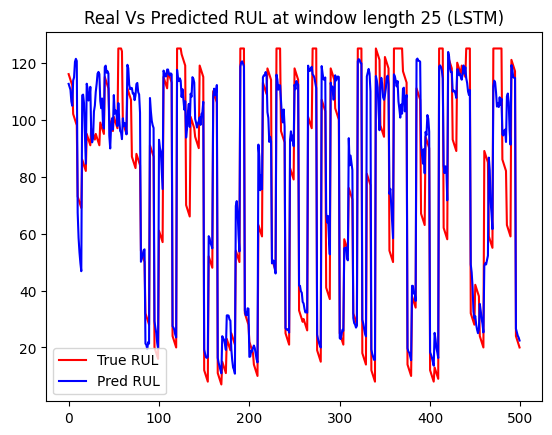

In [21]:
true_rul = LSTM_rresults[2]
rul_pred = LSTM_rresults[1]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 25 (LSTM)")
plt.legend()
plt.show()

# TSMixer

In [ ]:
window_length= 25
num_features = 15
shift = 1
num_last = 5
scaling = "MinMax"

TSMixer_results= TSMixer_modelling(window_length, shift, num_last, scaling,
                      hyperparameter_tuning, download=True)

In [28]:
print("Best Performance at window length 25 (TSMixer):")
print(TSMixer_results[0])

Best Performance at window length 25 (TSMixer):
{'MAE': 10.386536598205566, 'R2': 0.8754871487617493, 'RMSE': 14.046454061580864, 'S-score': 2026.2609431957253}


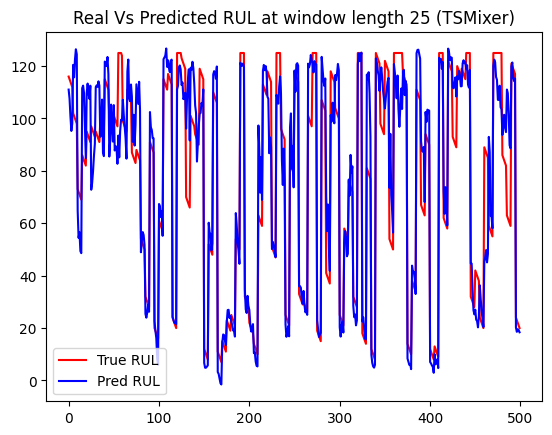

In [27]:
true_rul = TSMixer_results[2]
rul_pred = TSMixer_results[1]

plt.plot(true_rul, label = "True RUL", color = "red")
plt.plot(rul_pred, label = "Pred RUL", color = "blue")
plt.title("Real Vs Predicted RUL at window length 25 (TSMixer)")
plt.legend()
plt.show()

# SHAP

CNN model is used over LSTM due to technical limitations of SHAP , future studies to be perform to implement LSTM with SHAP.

In [16]:
model = tf.keras.models.load_model("cnn_model.keras")
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_6 (Conv1D)           (None, 25, 128)           9728      
                                                                 
 conv1d_7 (Conv1D)           (None, 25, 96)            61536     
                                                                 
 conv1d_8 (Conv1D)           (None, 25, 32)            9248      
                                                                 
 global_average_pooling1d_2   (None, 32)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_6 (Dense)             (None, 64)                2112      
                                                                 
 dense_7 (Dense)             (None, 128)               8320      
                                                      

In [18]:
input_scaler = joblib.load("MinMax.pkl")
target_scaler = joblib.load("target_scaler_cnn.pkl")

In [19]:
y_min = target_scaler.data_min_[0]
y_max = target_scaler.data_max_[0]
print(y_min,y_max)
scaler = y_max - y_min
print(scaler)



0.0 125.0
125.0


In [21]:
window_length = 25
shift = 1
num_last = 5
scaling = "MinMax"

processed_train_data, processed_train_targets, \
processed_test_data, true_rul, num_test_windows_list = windows_performance(
    window_length=window_length,
    shift=shift,
    num_last=num_last,
    scaling=scaling,
    download=False
)

print(processed_train_data.shape)
print(processed_test_data.shape)

Index([   26,    27,    28,    29,    30,    75,    76,    77,    78,    79,
       ...
       12893, 12894, 12895, 12896, 12897, 13091, 13092, 13093, 13094, 13095],
      dtype='int64', length=500)
Number of machines:  100
Processed trianing data shape:  (18231, 25, 15)
Processed training ruls shape:  (18231,)
Processed test data shape:  (500, 25, 15)
True RUL shape:  (500,)
Processed train data shape:  (18231, 25, 15)
Processed test data shape:  (500, 25, 15)
(18231, 25, 15)
(500, 25, 15)


In [22]:
actual_feature_names = [
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_6', 'sensor_7',
    'sensor_8', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13',
    'sensor_14', 'sensor_16', 'sensor_19', 'sensor_20', 'sensor_21'
]

np.random.seed(42)

background_data = processed_train_data[
    np.random.choice(processed_train_data.shape[0], 100, replace=False)
]



In [26]:
explainer = shap.DeepExplainer(model, background_data)

sample_indices = np.random.choice(processed_test_data.shape[0], 50, replace=False)
sample_test_data = processed_test_data[sample_indices]

shap_values = (explainer.shap_values(sample_test_data))*scaler*25

c:\Users\tvlan\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\tvlan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [27]:
if isinstance(shap_values, list):
    shap_values = shap_values[0] 
    
print(shap_values.shape)


(50, 25, 15, 1)


In [28]:
aggregated_shap_values = np.mean(shap_values, axis=1)  # shape: (samples, features)
aggregated_sample_test_data = np.mean(sample_test_data, axis=1)  # shape: (samples, features)

shap_values_squeezed = np.squeeze(aggregated_shap_values)

print("SHAP values shape:", shap_values_squeezed.shape)
print("Data shape:", aggregated_sample_test_data.shape)
print("Feature names:", len(actual_feature_names))


SHAP values shape: (50, 15)
Data shape: (50, 15)
Feature names: 15


C:\Users\tvlan\AppData\Local\Temp\ipykernel_25616\4199725668.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


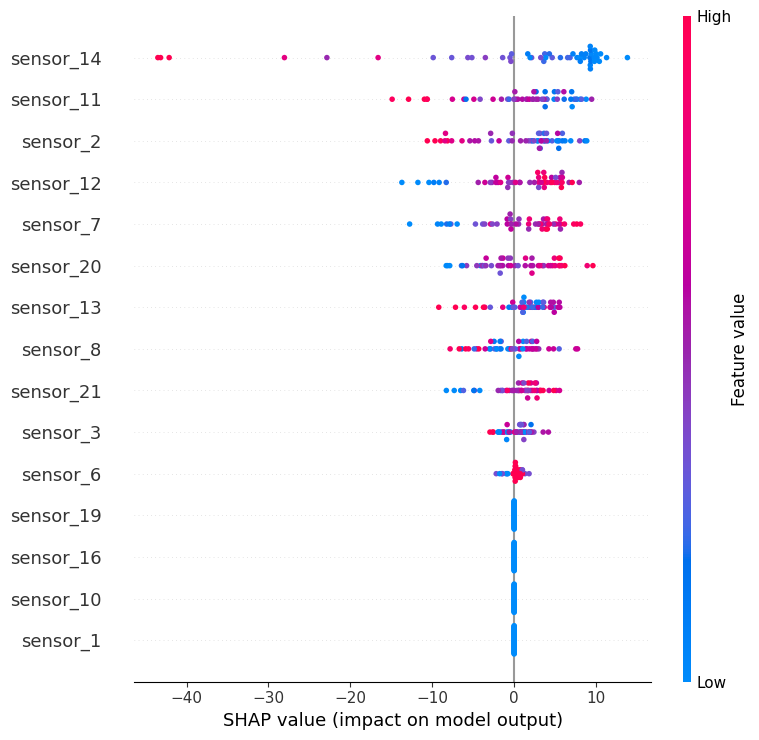

In [29]:
shap.summary_plot(
    shap_values_squeezed,
    aggregated_sample_test_data,
    feature_names=actual_feature_names,
    plot_type="dot"
)